In [1]:
import sys as _sys
from pathlib import Path as _Path
try:
    _sys.path.insert(0, str(_Path(__vsc_ipynb_file__).parent.parent))
except NameError:
    pass  # Not in VS Code; rely on pip install -e .

import os
from scripts.utils import setup_notebook, OKABE_ITO_CYCLE

PROJECT_ROOT, np, pd, plt, Path = setup_notebook()

from scripts.data_loader import AHE_hysteresis
from scripts.ahe_collection import AHE_Collection

color_values = OKABE_ITO_CYCLE
Save = True

BASE_DIR     = PROJECT_ROOT   # alias for cells that reference BASE_DIR directly
RAW_DATA_DIR = PROJECT_ROOT / "data" / "Minor loops" / "Minor loop wPF"
PLOTS_DIR    = PROJECT_ROOT / "figures"
RESULTS_DIR  = PROJECT_ROOT / "results"
PLOTS_DIR.mkdir(exist_ok=True)

folder = RAW_DATA_DIR
print(f"Raw data folder: {RAW_DATA_DIR}")
print(f"Figures folder: {PLOTS_DIR}")

[OK] Autoreload enabled
[OK] Project root: c:\Users\sadit\OneDrive - JGU\Projects\EB-in FGT-CrSBr
[OK] Matplotlib configured (Okabe-Ito palette, publication style)
Setup complete!
Raw data folder: c:\Users\sadit\OneDrive - JGU\Projects\EB-in FGT-CrSBr\data\Minor loops\Minor loop wPF
Figures folder: c:\Users\sadit\OneDrive - JGU\Projects\EB-in FGT-CrSBr\figures


In [2]:
custom_keys = {
    "Minor_loops_PF2500mT_20250325_2005__10K.h5": "Loop 1",
    "Minor_loops_PF2500mT_20250325_2230__10K.h5": "Loop 2",
    "Minor_loops_PF2500mT_20250326_0034__10K.h5": "Loop 3",
    "Minor_loops_PF2500mT_20250326_0219__10K.h5": "Loop 4"
}
EBvT_PF_P = AHE_Collection(RAW_DATA_DIR, custom_keys)
print(EBvT_PF_P.measurements.items())

dict_items([('Loop 1', <scripts.data_loader.AHE_hysteresis object at 0x000002544C6F9400>), ('Loop 2', <scripts.data_loader.AHE_hysteresis object at 0x000002544C60BED0>), ('Loop 3', <scripts.data_loader.AHE_hysteresis object at 0x0000025448ED1D10>), ('Loop 4', <scripts.data_loader.AHE_hysteresis object at 0x000002544C66F5C0>)])


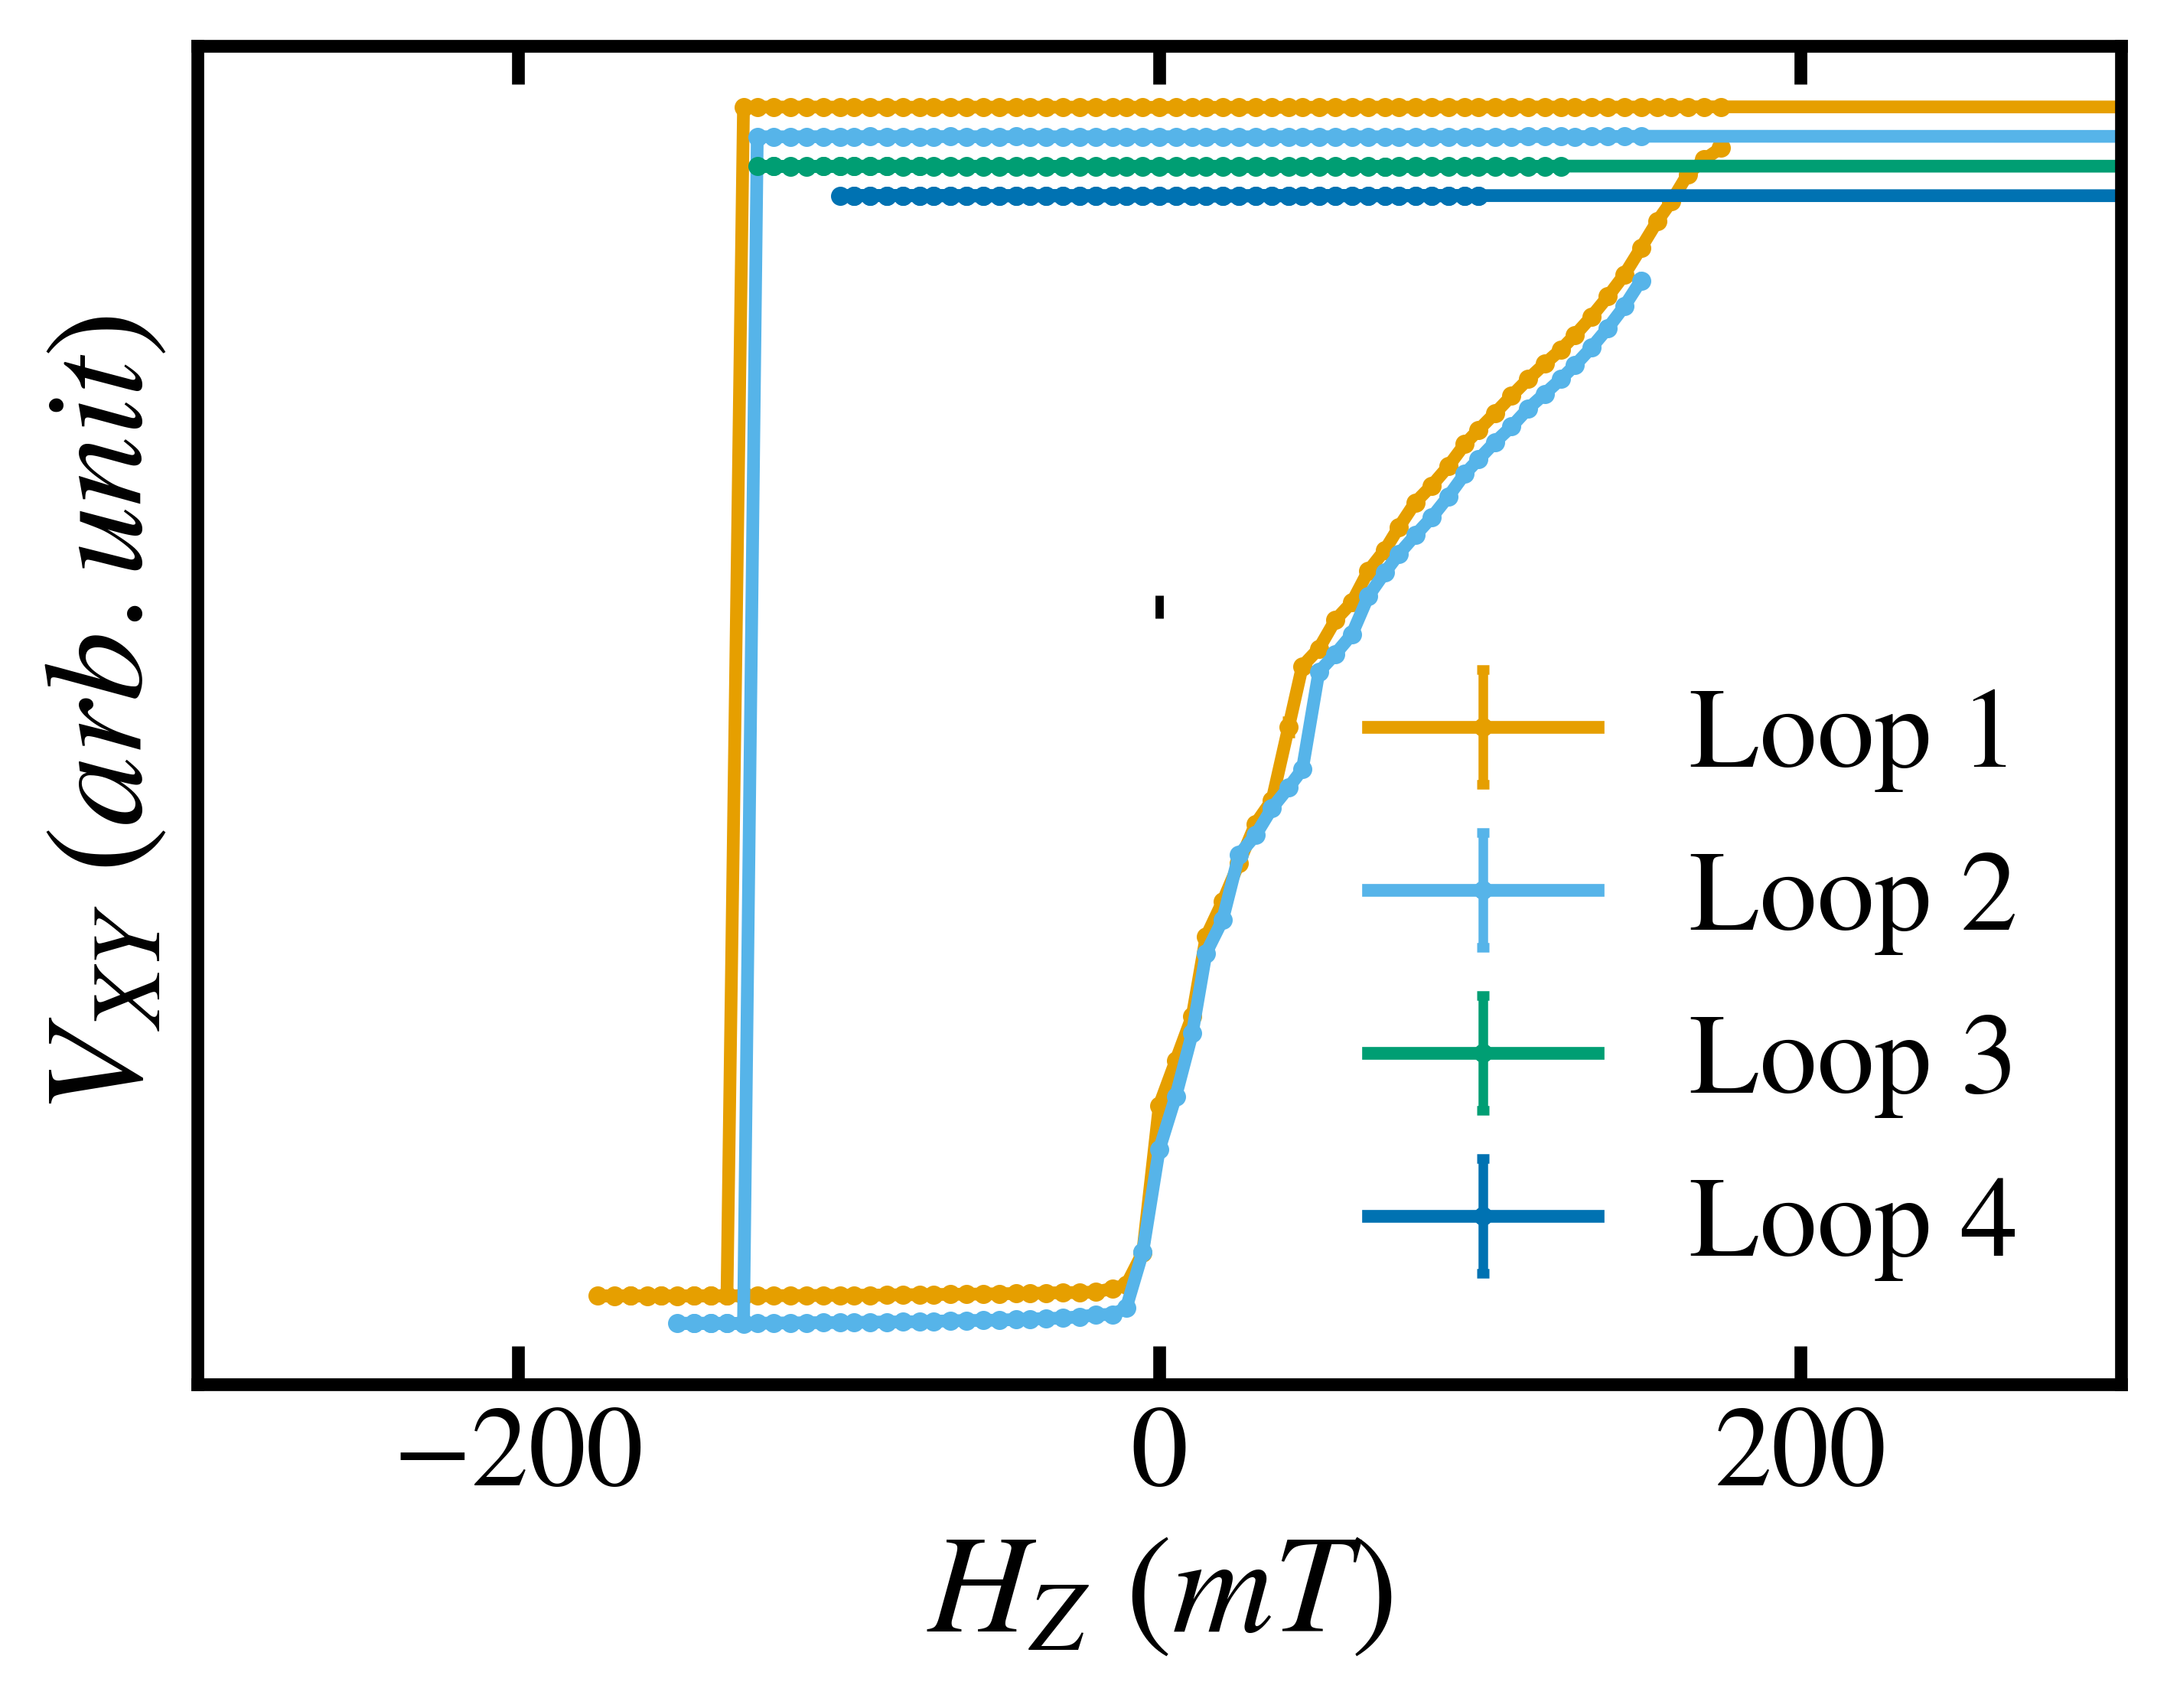

In [3]:
fig, ax = plt.subplots(figsize=(5, 4), dpi=600)

for i, (key, obj) in enumerate(EBvT_PF_P.measurements.items()):
    vspacing = 3
    color = color_values[i % len(color_values)]
    ax.errorbar(obj.field, obj.vxy - i * vspacing, obj.vxy_err, fmt='-o',
    color=color,
    label=key,
    capsize=1, markersize = 1.5,
    elinewidth=1.5,
    markeredgewidth=1.5)



# --- Vertical zero line ---
ax.plot([0, 0], [1.2, -1.2], color='k', linestyle='--', linewidth=1.3)

ax.set_xlabel("$H_Z$ $(mT)$")
ax.set_ylabel("$V_{XY}$ $(arb. unit)$")
ax.set_yticks([])  # Remove y-axis ticks for clean stacking
ax.legend(loc='lower right',  frameon=False)
plt.tight_layout()
plt.xlim(-300,300)




plt.savefig(os.path.join(PLOTS_DIR,"minor_loops_WPF.png"))
plt.show()

In [4]:
RAW_DATA_DIR_minor_loops_woPF = os.path.join(BASE_DIR, "data/Minor loops/Minor loop w training effect")

In [5]:
custom_keys2 = {
    "Zero_EB_minor_loops_0_20250330_0000__10K.h5": "Loop 1",
    "Zero_EB_minor_loops_20250328_1400__10K.h5": "Loop 2",
    "Zero_EB_minor_loops_20250328_1632__10K.h5": "Loop 3",
    "Zero_EB_minor_loops_20250328_1845__10K.h5": "Loop 4",
    "Zero_EB_minor_loops_20250328_2039__10K.h5": "Loop 5",
    "Zero_EB_minor_loops_20250328_2214__10K.h5": "Loop 6",
    "Zero_EB_minor_loops_20250328_2330__10K.h5": "Loop 7",
    "Zero_EB_minor_loops_20250329_0028__10K.h5": "Loop 8"
}
minor_loop_woPF = AHE_Collection(RAW_DATA_DIR_minor_loops_woPF, custom_keys2)
print(EBvT_PF_P.measurements.items())

dict_items([('Loop 1', <scripts.data_loader.AHE_hysteresis object at 0x000002544C6F9400>), ('Loop 2', <scripts.data_loader.AHE_hysteresis object at 0x000002544C60BED0>), ('Loop 3', <scripts.data_loader.AHE_hysteresis object at 0x0000025448ED1D10>), ('Loop 4', <scripts.data_loader.AHE_hysteresis object at 0x000002544C66F5C0>)])


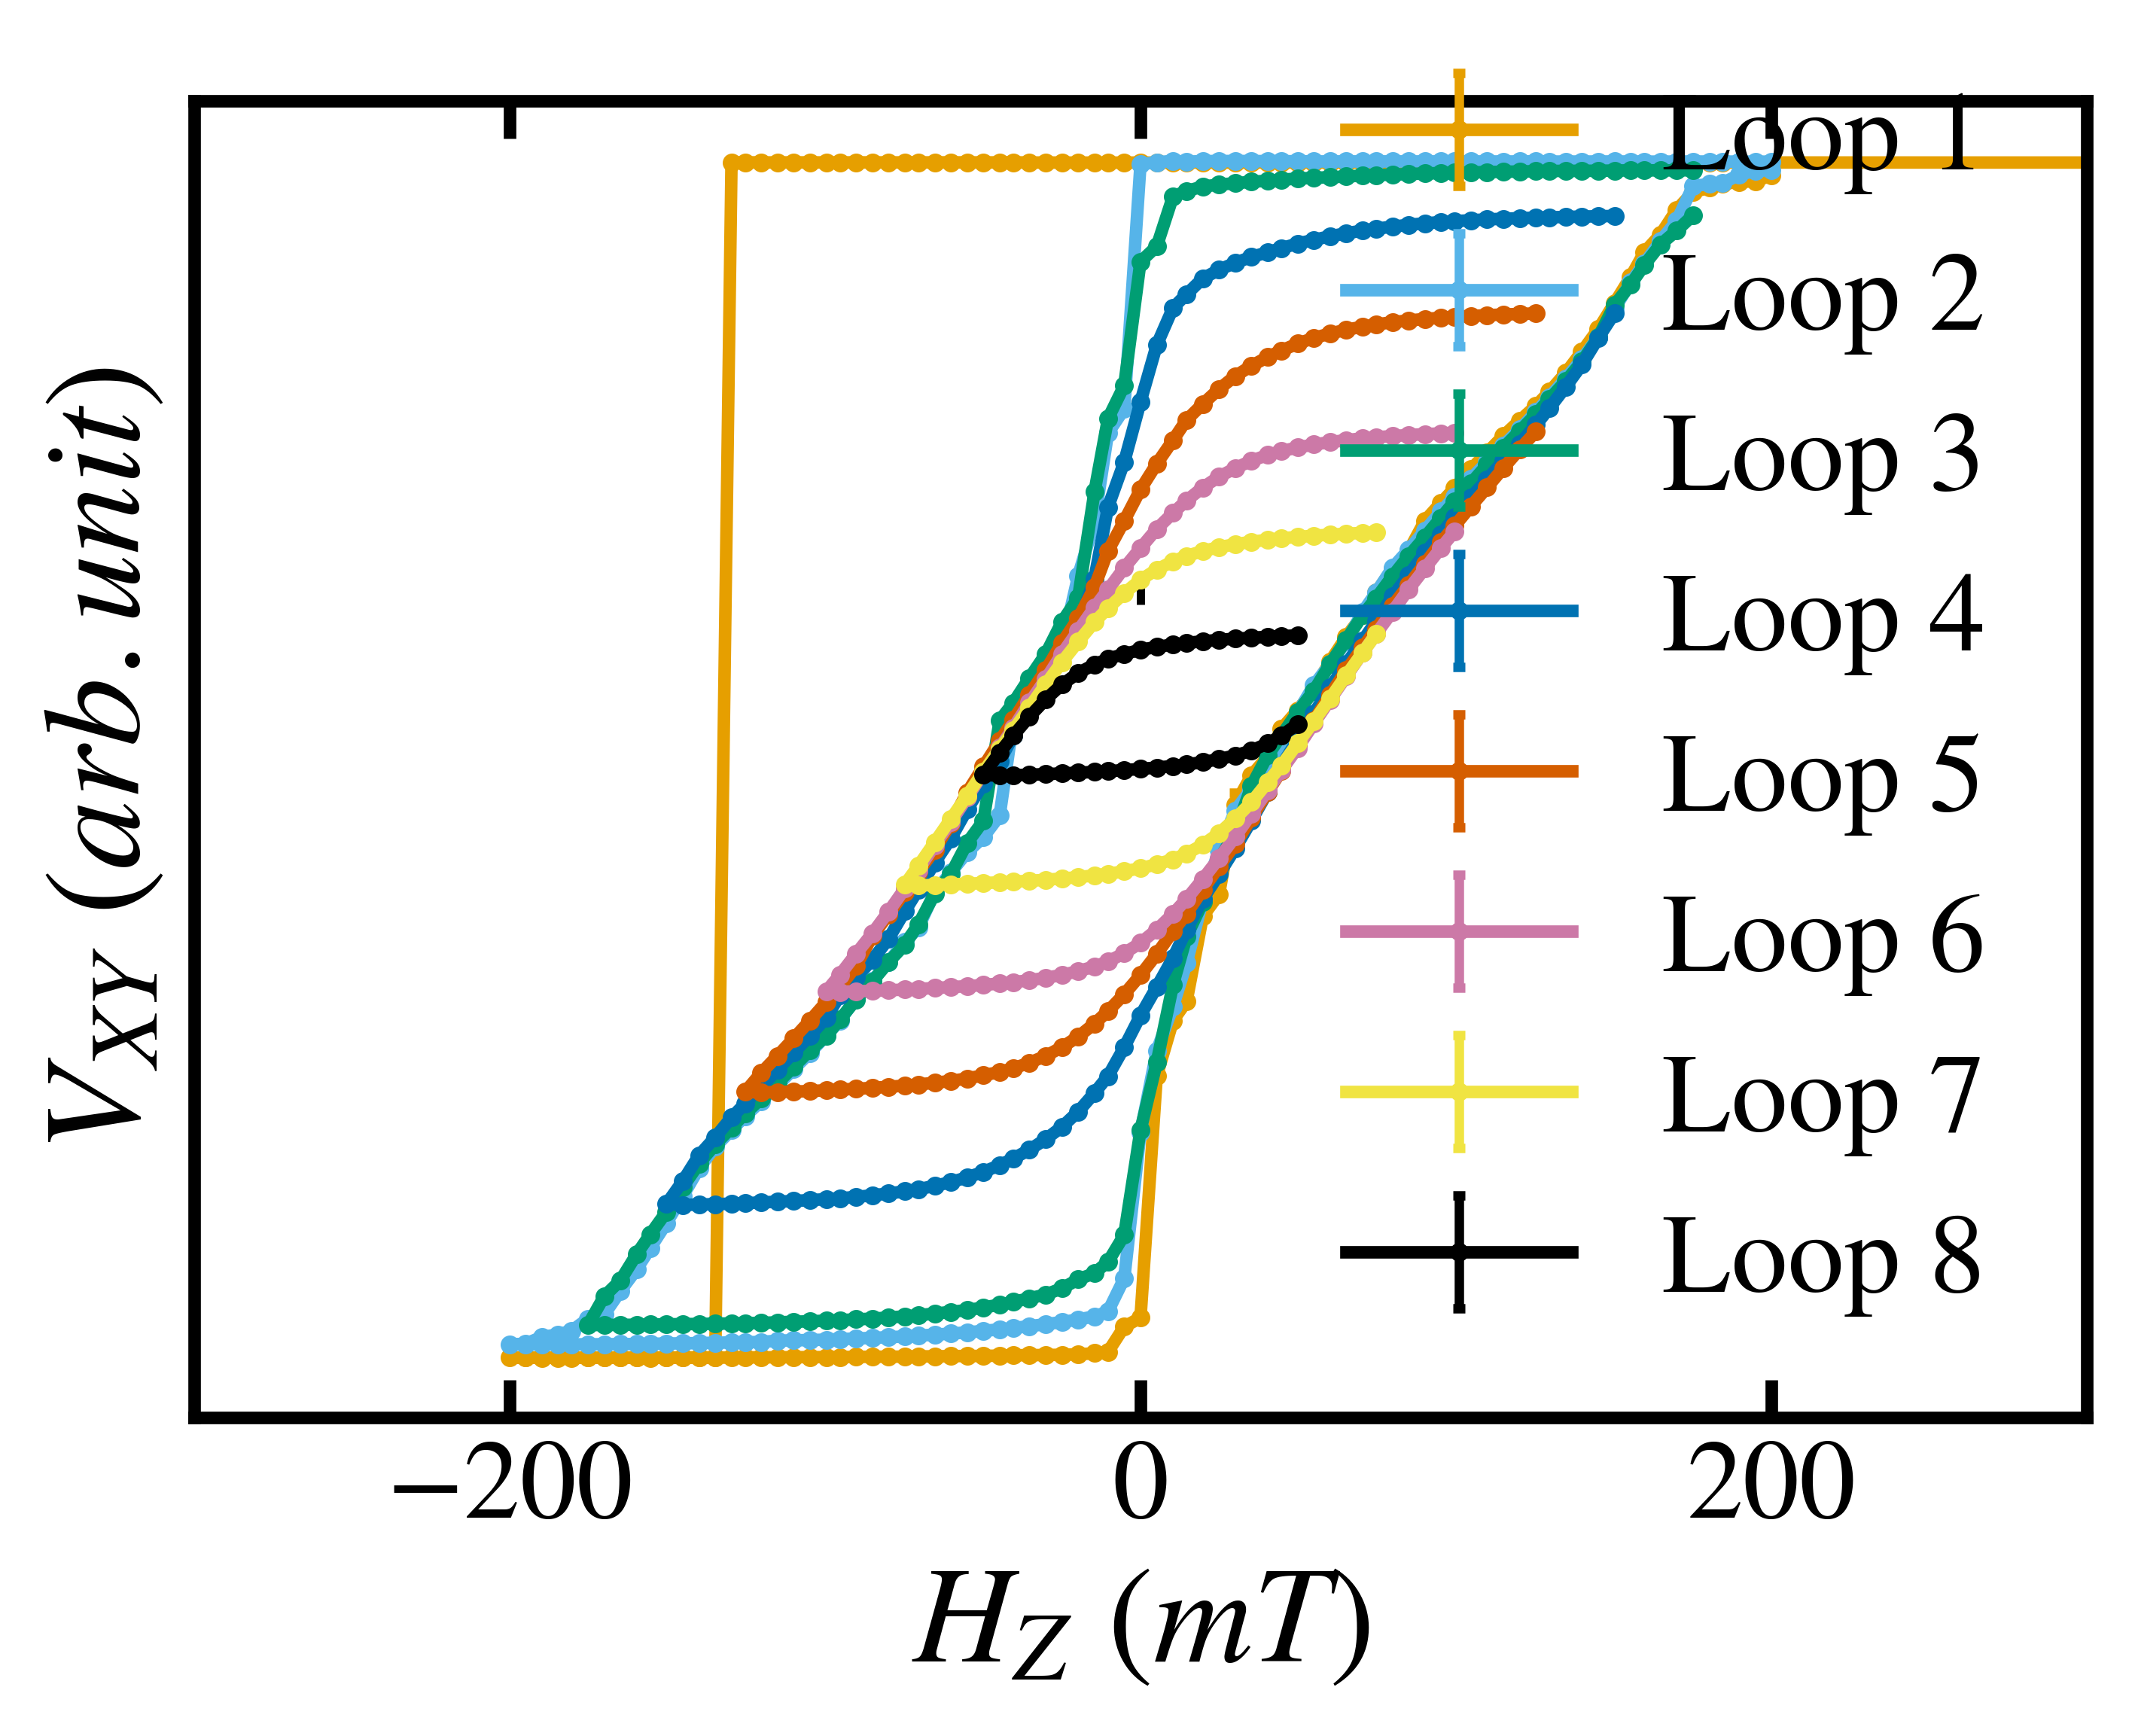

In [6]:
fig, ax = plt.subplots(figsize=(5, 4), dpi=600)

for i, (key, obj) in enumerate(minor_loop_woPF.measurements.items()):
    vspacing = 0
    color = color_values[i % len(color_values)]
    ax.errorbar(obj.field, obj.vxy - i * vspacing, obj.vxy_err, fmt='-o',
    color=color,
    label=key,
    capsize=1, markersize = 1.5,
    elinewidth=1.5,
    markeredgewidth=1.5)



# --- Vertical zero line ---
ax.plot([0, 0], [1.2, -1.2], color='k', linestyle='--', linewidth=1.3)

ax.set_xlabel("$H_Z$ $(mT)$")
ax.set_ylabel("$V_{XY}$ $(arb. unit)$")
ax.set_yticks([])  # Remove y-axis ticks for clean stacking
ax.legend(loc='lower right',  frameon=False)
plt.tight_layout()
plt.xlim(-300,300)




plt.savefig(os.path.join(PLOTS_DIR,"minor_loops_WOPF.png"))
plt.show()